    # MODULO5 Talento Altamente Especializado --> IA

    *Professor**: Dr German Pinedo
    **Nombre**: Cesar Eduardo Inda Ceniceros  

# M5.5 Masked Autoencoder (MAE)

Here **MAE** means *masked autoencoder*, not mean absolute error. The model learns by hiding most image patches and reconstructing their pixels:

$$x \rightarrow \text{patches} \rightarrow \text{mask 75\%} \rightarrow \text{encoder} \rightarrow \text{decoder} \rightarrow \hat{x}$$

We pretrain on **Cats vs Dogs**. Folder `0/` contains cats and `1/` contains dogs, but these labels are ignored during pretraining. They are used only to inspect the learned latent codification at the end.

In [1]:
!pip install torchinfo

In [2]:
from pathlib import Path

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from torchinfo import summary

SEED = 42
DATA_DIR = Path("./data/catsvsdogs")
IMAGE_SIZE = 64
PATCH_SIZE = 8
MASK_RATIO = 0.75
BATCH_SIZE = 64
EPOCHS = 5
LEARNING_RATE = 1e-3

EMBED_DIM = 128
ENCODER_DEPTH = 3
ENCODER_HEADS = 4
DECODER_DIM = 64
DECODER_DEPTH = 2
DECODER_HEADS = 4

torch.manual_seed(SEED)
np.random.seed(SEED)


def get_device():
    if torch.cuda.is_available():
        return torch.device("cuda")
    if torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


device = get_device()
print(f"Using device: {device}")

Using device: cuda


In [3]:
from pathlib import Path
import zipfile
import shutil

# Archivo ZIP ubicado junto a la libreta.
zip_path = Path("./catsvsdogs.zip")

assert zip_path.exists(), (
    f"No se encontró {zip_path.resolve()}\n"
    "Coloca catsvsdogs.zip en la misma carpeta que la libreta."
)

DATA_DIR = Path("./data/catsvsdogs")
TEMP_DIR = Path("./data/_catsvsdogs_extracted")

# Preparar una carpeta temporal de extracción.
if TEMP_DIR.exists():
    shutil.rmtree(TEMP_DIR)

TEMP_DIR.mkdir(parents=True, exist_ok=True)

# Extraer el archivo.
with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(TEMP_DIR)

# Buscar una carpeta que contenga directamente las clases 0 y 1.
directories = [TEMP_DIR] + [p for p in TEMP_DIR.rglob("*") if p.is_dir()]

source_dir = next(
    (
        directory
        for directory in directories
        if (directory / "0").is_dir() and (directory / "1").is_dir()
    ),
    None,
)

assert source_dir is not None, (
    "No se encontraron las carpetas de clases 0 y 1 dentro del ZIP."
)

# Dejar el dataset en ./data/catsvsdogs/0 y ./data/catsvsdogs/1.
if DATA_DIR.exists():
    shutil.rmtree(DATA_DIR)

DATA_DIR.parent.mkdir(parents=True, exist_ok=True)
shutil.move(str(source_dir), str(DATA_DIR))

# Eliminar los archivos temporales restantes.
if TEMP_DIR.exists():
    shutil.rmtree(TEMP_DIR)

cats = [p for p in (DATA_DIR / "0").iterdir() if p.is_file()]
dogs = [p for p in (DATA_DIR / "1").iterdir() if p.is_file()]

print(f"Dataset listo en: {DATA_DIR.resolve()}")
print(f"Gatos: {len(cats)}")
print(f"Perros: {len(dogs)}")

Dataset listo en: C:\Specialization_Artificial_Intelligence_Cinvestav\Module5_MartinPerez\data\catsvsdogs
Gatos: 12501
Perros: 12501


In [4]:
"""""
from google.colab import files
import zipfile
import shutil

uploaded = files.upload()
zip_name = "catsvsdogs.zip"
assert zip_name in uploaded, f"Se esperaba el archivo {zip_name}"

DATA_DIR = Path("./data/catsvsdogs")
DATA_DIR.parent.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(zip_name, "r") as zip_ref:
    zip_ref.extractall(DATA_DIR.parent)

# Ajusta la carpeta extraída para que ImageFolder encuentre exactamente ./data/catsvsdogs/0 y ./data/catsvsdogs/1.
if not (DATA_DIR / "0").exists() or not (DATA_DIR / "1").exists():
    candidates = [p for p in DATA_DIR.parent.iterdir() if p.is_dir()]
    source_dir = next((p for p in candidates if (p / "0").exists() and (p / "1").exists()), None)
    assert source_dir is not None, "El ZIP debe contener las carpetas 0 y 1 (cat y dog)."
    if source_dir != DATA_DIR:
        if DATA_DIR.exists():
            shutil.rmtree(DATA_DIR)
        source_dir.rename(DATA_DIR)

print(f"Dataset listo en: {DATA_DIR.resolve()}")
print(f"Gatos: {len(list((DATA_DIR / '0').glob('*')))}")
print(f"Perros: {len(list((DATA_DIR / '1').glob('*')))}")
"""""


'""\nfrom google.colab import files\nimport zipfile\nimport shutil\n\nuploaded = files.upload()\nzip_name = "catsvsdogs.zip"\nassert zip_name in uploaded, f"Se esperaba el archivo {zip_name}"\n\nDATA_DIR = Path("./data/catsvsdogs")\nDATA_DIR.parent.mkdir(parents=True, exist_ok=True)\n\nwith zipfile.ZipFile(zip_name, "r") as zip_ref:\n    zip_ref.extractall(DATA_DIR.parent)\n\n# Ajusta la carpeta extraída para que ImageFolder encuentre exactamente ./data/catsvsdogs/0 y ./data/catsvsdogs/1.\nif not (DATA_DIR / "0").exists() or not (DATA_DIR / "1").exists():\n    candidates = [p for p in DATA_DIR.parent.iterdir() if p.is_dir()]\n    source_dir = next((p for p in candidates if (p / "0").exists() and (p / "1").exists()), None)\n    assert source_dir is not None, "El ZIP debe contener las carpetas 0 y 1 (cat y dog)."\n    if source_dir != DATA_DIR:\n        if DATA_DIR.exists():\n            shutil.rmtree(DATA_DIR)\n        source_dir.rename(DATA_DIR)\n\nprint(f"Dataset listo en: {DATA_DIR.r

## Cats vs Dogs dataset

`ImageFolder` reads the folder names as class IDs, so `0 → cat` and `1 → dog`. We make a seeded 80/20 split. Random crops and horizontal flips are used only for pretraining; validation images use a deterministic center crop.

The training loop will use `for images, _ in loader`: the underscore makes explicit that class labels are not part of the MAE objective.

Classes: {'0': 0, '1': 1} (0=cat, 1=dog)
Pretraining images: 20000
Validation images: 5000


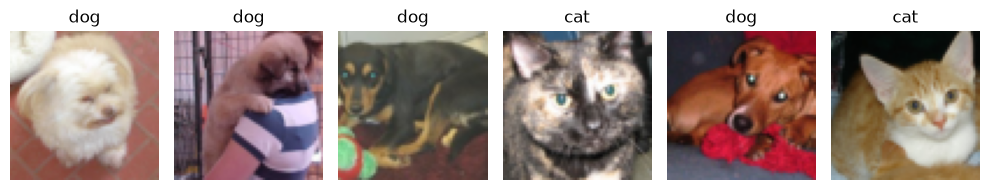

In [5]:
assert DATA_DIR.exists(), f"Dataset not found: {DATA_DIR.resolve()}"

train_transform = transforms.Compose([
    transforms.Resize(72),
    transforms.RandomCrop(IMAGE_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
])
evaluation_transform = transforms.Compose([
    transforms.Resize(72),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
])

index_dataset = datasets.ImageFolder(DATA_DIR)
assert index_dataset.class_to_idx == {"0": 0, "1": 1}
class_names = {0: "cat", 1: "dog"}

split_generator = torch.Generator().manual_seed(SEED)
indices = torch.randperm(len(index_dataset), generator=split_generator)
train_size = int(0.80 * len(indices))
train_indices = indices[:train_size].tolist()
validation_indices = indices[train_size:].tolist()

train_source = datasets.ImageFolder(DATA_DIR, transform=train_transform)
validation_source = datasets.ImageFolder(DATA_DIR, transform=evaluation_transform)
train_dataset = Subset(train_source, train_indices)
validation_dataset = Subset(validation_source, validation_indices)

loader_generator = torch.Generator().manual_seed(SEED)
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=(device.type == "cuda"),
    generator=loader_generator,
)
validation_loader = DataLoader(
    validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=(device.type == "cuda"),
)

print(f"Classes: {index_dataset.class_to_idx} (0=cat, 1=dog)")
print(f"Pretraining images: {len(train_dataset)}")
print(f"Validation images: {len(validation_dataset)}")

preview_images, preview_labels = next(iter(validation_loader))
fig, axes = plt.subplots(1, 6, figsize=(10, 2.2))
for image, label, ax in zip(preview_images, preview_labels, axes):
    ax.imshow(image.permute(1, 2, 0))
    ax.set_title(class_names[label.item()])
    ax.axis("off")
plt.tight_layout()
plt.show()

## Step 1 — Convert images into patches

For an image of size $H\times W$ and square patches of side $P$, the number of patches is

$$N=\frac{H}{P}\frac{W}{P}.$$

With $64\times64$ RGB images and $8\times8$ patches, $N=64$ and every flattened patch contains $8\cdot8\cdot3=192$ values. `patchify` and `unpatchify` only rearrange values, so a round trip must recover the original image exactly.

In [6]:
def patchify(images, patch_size=PATCH_SIZE):
    'Convert [B, C, H, W] images to [B, N, P*P*C] patches.'
    batch, channels, height, width = images.shape
    assert height == width and height % patch_size == 0
    grid = height // patch_size

    patches = images.reshape(
        batch, channels, grid, patch_size, grid, patch_size
    )
    patches = patches.permute(0, 2, 4, 3, 5, 1)
    return patches.reshape(batch, grid * grid, patch_size * patch_size * channels)


def unpatchify(patches, patch_size=PATCH_SIZE):
    'Convert [B, N, P*P*C] patches back to [B, C, H, W].'
    batch, num_patches, patch_dim = patches.shape
    grid = int(num_patches**0.5)
    assert grid * grid == num_patches
    channels = patch_dim // (patch_size * patch_size)

    images = patches.reshape(
        batch, grid, grid, patch_size, patch_size, channels
    )
    images = images.permute(0, 5, 1, 3, 2, 4)
    return images.reshape(
        batch, channels, grid * patch_size, grid * patch_size
    )


patch_demo = patchify(preview_images[:2])
round_trip = unpatchify(patch_demo)
torch.testing.assert_close(round_trip, preview_images[:2])

print("images:", tuple(preview_images[:2].shape))
print("patches:", tuple(patch_demo.shape))
print("round-trip check passed")

images: (2, 3, 64, 64)
patches: (2, 64, 192)
round-trip check passed


## Step 2 — Hide random patches

Each image receives a different random ordering of its patches. We keep the first 25% of that ordering and record how to restore the original spatial order later.

The returned `mask` uses `0` for visible patches and `1` for hidden patches. Only `visible_tokens` enter the encoder.

**Exercise:** use `ids_keep` to gather the visible token vectors.

In [7]:
def random_masking(tokens, mask_ratio):
    'Keep a random subset of tokens independently for every image.'
    batch, num_patches, dim = tokens.shape
    num_keep = int(num_patches * (1 - mask_ratio))

    noise = torch.rand(batch, num_patches, device=tokens.device)
    ids_shuffle = torch.argsort(noise, dim=1)
    ids_restore = torch.argsort(ids_shuffle, dim=1)
    ids_keep = ids_shuffle[:, :num_keep]

    # TODO 1: Gather visible tokens; hint: torch.gather(tokens, 1, ids_keep.unsqueeze(-1).expand(-1, -1, dim)).
    visible_tokens = torch.gather(
        tokens, 1, ids_keep.unsqueeze(-1).expand(-1, -1, dim)
    )

    mask = torch.ones(batch, num_patches, device=tokens.device)
    mask[:, :num_keep] = 0
    mask = torch.gather(mask, dim=1, index=ids_restore)
    return visible_tokens, mask, ids_restore

## Step 3 — Encode visible patches and decode all positions

The patch embedding maps every patch to a token. The encoder processes only visible tokens. The decoder adds one learned `mask_token` per hidden position, restores the original order, and predicts the pixels of all patches.

For a deterministic latent code, `encode` processes every patch without masking and averages the encoded tokens:

$$h(x)=\frac{1}{N}\sum_{j=1}^{N}h_j.$$

**Exercise:** complete this mean pooling operation in `encode`.

In [8]:
class MaskedAutoencoder(nn.Module):
    def __init__(
        self,
        image_size=IMAGE_SIZE,
        patch_size=PATCH_SIZE,
        in_channels=3,
        embed_dim=EMBED_DIM,
        encoder_depth=ENCODER_DEPTH,
        encoder_heads=ENCODER_HEADS,
        decoder_dim=DECODER_DIM,
        decoder_depth=DECODER_DEPTH,
        decoder_heads=DECODER_HEADS,
    ):
        super().__init__()
        assert image_size % patch_size == 0

        self.patch_size = patch_size
        self.num_patches = (image_size // patch_size) ** 2
        self.patch_dim = patch_size * patch_size * in_channels
        self.decoder_dim = decoder_dim

        self.patch_embed = nn.Conv2d(
            in_channels,
            embed_dim,
            kernel_size=patch_size,
            stride=patch_size,
        )
        self.encoder_pos = nn.Parameter(
            torch.zeros(1, self.num_patches, embed_dim)
        )

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=encoder_heads,
            dim_feedforward=4 * embed_dim,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=encoder_depth,
            norm=nn.LayerNorm(embed_dim),
        )

        self.encoder_to_decoder = nn.Linear(embed_dim, decoder_dim)
        self.mask_token = nn.Parameter(torch.zeros(1, 1, decoder_dim))
        self.decoder_pos = nn.Parameter(
            torch.zeros(1, self.num_patches, decoder_dim)
        )

        decoder_layer = nn.TransformerEncoderLayer(
            d_model=decoder_dim,
            nhead=decoder_heads,
            dim_feedforward=4 * decoder_dim,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )
        self.decoder = nn.TransformerEncoder(
            decoder_layer,
            num_layers=decoder_depth,
            norm=nn.LayerNorm(decoder_dim),
        )
        self.decoder_prediction = nn.Linear(decoder_dim, self.patch_dim)

        nn.init.trunc_normal_(self.encoder_pos, std=0.02)
        nn.init.trunc_normal_(self.decoder_pos, std=0.02)
        nn.init.trunc_normal_(self.mask_token, std=0.02)

    def embed_patches(self, images):
        tokens = self.patch_embed(images)
        return tokens.flatten(2).transpose(1, 2)

    def forward_encoder(self, images, mask_ratio):
        tokens = self.embed_patches(images) + self.encoder_pos
        visible, mask, ids_restore = random_masking(tokens, mask_ratio)
        latent_tokens = self.encoder(visible)
        return latent_tokens, mask, ids_restore

    def forward_decoder(self, latent_tokens, ids_restore):
        visible = self.encoder_to_decoder(latent_tokens)
        num_hidden = ids_restore.size(1) - visible.size(1)
        mask_tokens = self.mask_token.expand(visible.size(0), num_hidden, -1)

        shuffled = torch.cat([visible, mask_tokens], dim=1)
        restore_index = ids_restore.unsqueeze(-1).expand(
            -1, -1, self.decoder_dim
        )
        restored = torch.gather(shuffled, dim=1, index=restore_index)

        decoded = self.decoder(restored + self.decoder_pos)
        return self.decoder_prediction(decoded)

    def forward(self, images, mask_ratio=MASK_RATIO):
        latent_tokens, mask, ids_restore = self.forward_encoder(
            images, mask_ratio
        )
        predicted_patches = self.forward_decoder(latent_tokens, ids_restore)
        return predicted_patches, mask, latent_tokens

    def encode(self, images):
        tokens = self.embed_patches(images) + self.encoder_pos
        encoded_tokens = self.encoder(tokens)

        # TODO 2: Create one code per image; hint: encoded_tokens.mean(dim=1).
        codes = encoded_tokens.mean(dim=1)
        return codes

In [9]:
mae = MaskedAutoencoder()
sample_images, _ = next(iter(train_loader))

summary(
    mae,
    input_data=sample_images[:2],
    col_names=("input_size", "output_size", "num_params"),
    depth=3,
)

with torch.no_grad():
    predicted_sample, mask_sample, latent_sample = mae(sample_images[:2])

print("predicted patches:", tuple(predicted_sample.shape))
print("mask:", tuple(mask_sample.shape))
print("visible latent tokens:", tuple(latent_sample.shape))
print(f"masked fraction: {mask_sample.float().mean().item():.2f}")

assert predicted_sample.shape == (2, 64, PATCH_SIZE * PATCH_SIZE * 3)
assert mask_sample.shape == (2, 64)
assert abs(mask_sample.float().mean().item() - MASK_RATIO) < 1e-6

C:\Users\tiori\AppData\Local\Temp\ipykernel_33272\1600403432.py:40: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(
C:\Users\tiori\AppData\Local\Temp\ipykernel_33272\1600403432.py:60: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.decoder = nn.TransformerEncoder(


predicted patches: (2, 64, 192)
mask: (2, 64)
visible latent tokens: (2, 16, 128)
masked fraction: 0.75


## Step 4 — Reconstruct only hidden patches

The decoder predicts every patch, but the objective scores only hidden ones. If $m_j=1$ means patch $j$ was hidden,

$$\mathcal{L}_{MAE}
=\frac{\sum_j m_j\,\operatorname{MSE}(\hat{p}_j,p_j)}{\sum_j m_j}.$$

Visible patches do not contribute to the loss. This prevents the model from solving the task by copying its input.

**Exercise:** compute one MSE per patch, then average only the positions where `mask == 1`.

In [10]:
def masked_patch_mse(predicted_patches, target_patches, mask):
    'Mean squared error over hidden patches only.'
    # TODO 3a: Compute one MSE per patch; hint: square the error, then mean(dim=-1).
    patch_mse = (predicted_patches - target_patches).pow(2).mean(dim=-1)

    # TODO 3b: Average only hidden patches; hint: (patch_mse * mask).sum() / mask.sum().clamp_min(1).
    return (patch_mse * mask).sum() / mask.sum().clamp_min(1)


def train_mae(model, loader, epochs=EPOCHS, lr=LEARNING_RATE):
    'Pretrain the MAE without using class labels.'
    model = model.to(device)
    optimizer = torch.optim.AdamW(
        model.parameters(), lr=lr, weight_decay=0.05
    )
    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0

        for images, _ in loader:
            images = images.to(device)
            target_patches = patchify(images, model.patch_size)

            optimizer.zero_grad(set_to_none=True)
            predicted_patches, mask, _ = model(images, MASK_RATIO)
            loss = masked_patch_mse(predicted_patches, target_patches, mask)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)

        epoch_loss = running_loss / len(loader.dataset)
        history.append(epoch_loss)
        print(f"epoch {epoch:2d}/{epochs} - masked MSE: {epoch_loss:.6f}")

    return history

## Self-supervised pretraining

The model receives images and random masks only. Cat/dog labels are present in the loader but deliberately discarded. A decreasing masked MSE means the model is learning visual structure from the visible context.

c:\Users\tiori\AppData\Local\Programs\Python\Python312\Lib\site-packages\PIL\TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Imágenes válidas para entrenamiento: 19999
Imágenes defectuosas excluidas: 1
  Excluida: data\catsvsdogs\1\11702.jpg
epoch  1/5 - masked MSE: 0.071130
epoch  2/5 - masked MSE: 0.053243
epoch  3/5 - masked MSE: 0.049178
epoch  4/5 - masked MSE: 0.042261
epoch  5/5 - masked MSE: 0.036898


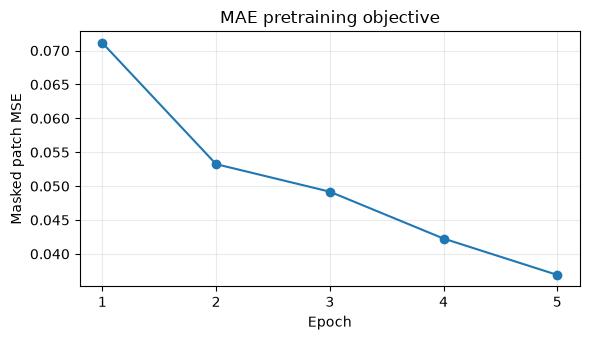

In [11]:
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from PIL import Image, UnidentifiedImageError
from torch.utils.data import DataLoader, Subset


def is_valid_image(image_path):
    """Comprueba que Pillow pueda identificar y decodificar la imagen."""
    try:
        with Image.open(image_path) as image:
            image.verify()

        with Image.open(image_path) as image:
            image.convert("RGB").load()

        return True

    except (
        UnidentifiedImageError,
        OSError,
        ValueError,
        SyntaxError
    ):
        return False


def remove_invalid_samples(loader):
    """
    Crea un DataLoader nuevo excluyendo las imágenes dañadas.
    Funciona cuando ImageFolder está dentro de un Subset.
    """
    current_dataset = loader.dataset

    if isinstance(current_dataset, Subset):
        base_dataset = current_dataset.dataset
        original_indices = list(current_dataset.indices)
    else:
        base_dataset = current_dataset
        original_indices = list(range(len(base_dataset)))

    if not hasattr(base_dataset, "samples"):
        raise TypeError(
            "El dataset debe haber sido creado con torchvision.datasets.ImageFolder."
        )

    valid_indices = []
    invalid_files = []

    for index in original_indices:
        image_path, _ = base_dataset.samples[index]

        if is_valid_image(image_path):
            valid_indices.append(index)
        else:
            invalid_files.append(image_path)

    if not valid_indices:
        raise RuntimeError("No se encontraron imágenes válidas para entrenar.")

    clean_dataset = Subset(base_dataset, valid_indices)

    clean_loader = DataLoader(
        clean_dataset,
        batch_size=loader.batch_size,
        shuffle=True,
        num_workers=loader.num_workers,
        pin_memory=loader.pin_memory,
        drop_last=loader.drop_last,
    )

    print(f"Imágenes válidas para entrenamiento: {len(valid_indices)}")
    print(f"Imágenes defectuosas excluidas: {len(invalid_files)}")

    for path in invalid_files:
        print(f"  Excluida: {Path(path)}")

    return clean_loader


# Limpiar y reconstruir el DataLoader
train_loader = remove_invalid_samples(train_loader)

# Entrenar el MAE
history = train_mae(mae, train_loader)

# Graficar únicamente las épocas que realmente terminaron
epochs_completed = np.arange(1, len(history) + 1)

plt.figure(figsize=(6, 3.5))
plt.plot(epochs_completed, history, marker="o")
plt.title("MAE pretraining objective")
plt.xlabel("Epoch")
plt.ylabel("Masked patch MSE")
plt.xticks(epochs_completed)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## Masked reconstruction

For visualization, hidden patches are shown in gray. The completed image keeps the original visible patches and fills only the hidden positions with decoder predictions.

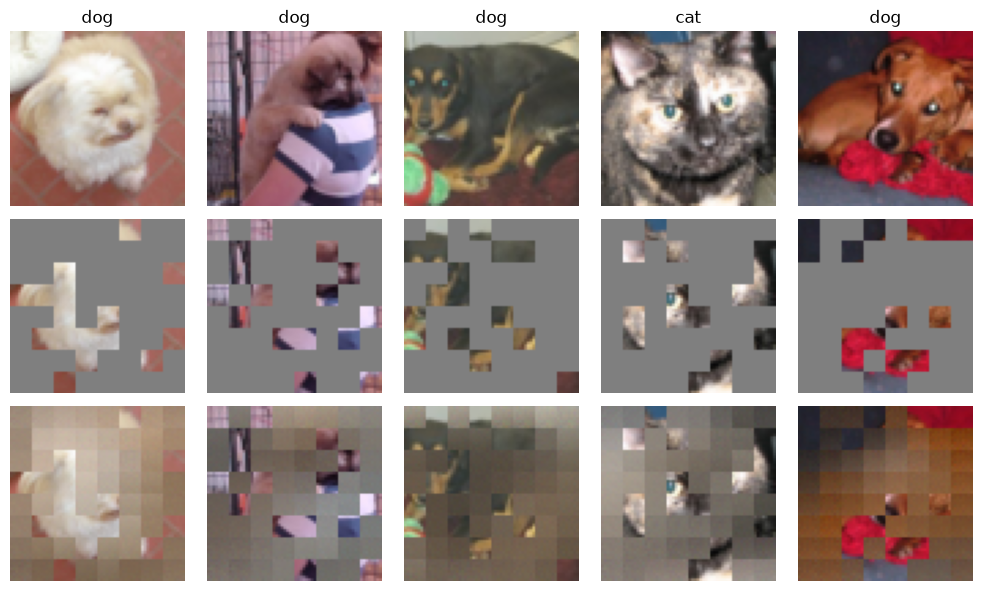

In [12]:
mae.eval()
torch.manual_seed(7)
images_to_show = preview_images[:5].to(device)

with torch.no_grad():
    predicted_patches, mask, _ = mae(images_to_show, MASK_RATIO)

predicted_images = unpatchify(
    predicted_patches, mae.patch_size
).clamp(0, 1).cpu()
original_images = images_to_show.cpu()

mask_patches = mask.unsqueeze(-1).expand(-1, -1, mae.patch_dim)
mask_images = unpatchify(mask_patches, mae.patch_size).cpu()
masked_images = original_images * (1 - mask_images) + 0.5 * mask_images
completed_images = (
    original_images * (1 - mask_images) + predicted_images * mask_images
)

rows = [original_images, masked_images, completed_images]
row_names = ["original", "masked", "completed"]
fig, axes = plt.subplots(3, 5, figsize=(10, 6))

for row, (images, row_name) in enumerate(zip(rows, row_names)):
    for column, image in enumerate(images):
        axes[row, column].imshow(image.permute(1, 2, 0))
        axes[row, column].axis("off")
    axes[row, 0].set_ylabel(row_name)

for column, label in enumerate(preview_labels[:5]):
    axes[0, column].set_title(class_names[label.item()])

plt.tight_layout()
plt.show()

## Latent codification

To obtain a stable representation, `encode` uses every patch and mean-pools the encoder tokens into one $128$-dimensional vector per image. We project held-out vectors to two dimensions with PCA.

Cat/dog labels are used only to color the plot. Separation is informative, but it is not guaranteed because the MAE was trained to reconstruct pixels rather than classify animals.

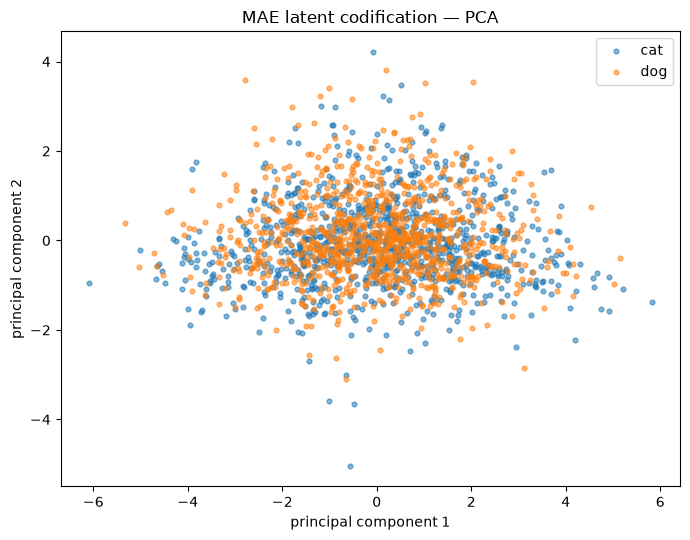

latent codes: (2000, 128)
PCA projection: (2000, 2)


In [13]:
def collect_codes(model, loader, max_samples=2000):
    'Collect deterministic encoder codes from held-out images.'
    model.eval()
    codes, labels = [], []

    with torch.no_grad():
        for images, y in loader:
            codes.append(model.encode(images.to(device)).cpu())
            labels.append(y)
            if sum(batch.size(0) for batch in codes) >= max_samples:
                break

    codes = torch.cat(codes)[:max_samples]
    labels = torch.cat(labels)[:max_samples]
    return codes, labels


latent_codes, latent_labels = collect_codes(mae, validation_loader)
centered_codes = latent_codes - latent_codes.mean(dim=0, keepdim=True)

torch.manual_seed(SEED)
_, _, components = torch.pca_lowrank(centered_codes, q=2, center=False)
latent_2d = centered_codes @ components

fig, ax = plt.subplots(figsize=(7, 5.5))
for label, color in [(0, "tab:blue"), (1, "tab:orange")]:
    selected = latent_labels == label
    ax.scatter(
        latent_2d[selected, 0],
        latent_2d[selected, 1],
        s=12,
        alpha=0.55,
        color=color,
        label=class_names[label],
    )

ax.set_title("MAE latent codification — PCA")
ax.set_xlabel("principal component 1")
ax.set_ylabel("principal component 2")
ax.legend()
plt.tight_layout()
plt.show()

print("latent codes:", tuple(latent_codes.shape))
print("PCA projection:", tuple(latent_2d.shape))

## Key points

- The image is divided into non-overlapping patches and 75% are hidden.
- The encoder processes only visible tokens; a lightweight decoder reconstructs all patch positions.
- The loss is pixel MSE on hidden patches only.
- Pretraining is self-supervised: cat/dog labels are not used.
- The latent code is deterministic and comes from mean-pooled encoder tokens.
- Unlike a VAE, an MAE has no KL term, `mu`, `logvar`, or normal-prior sampling.